In [24]:
import pandas as pd
import numpy as np

In [25]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [26]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [27]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [28]:
df.shape

(5572, 5)

In [29]:
## drop last 3 columns

df.drop(columns=['Unnamed: 2', 'Unnamed: 3' , 'Unnamed: 4'],inplace=True)

In [30]:
df.sample(5)


,v1,v2
4808,ham,"Don't worry though, I understand how important..."
2105,ham,I fetch yun or u fetch?
37,ham,I see the letter B on my car
3221,ham,"Hi, my love! How goes that day? Fuck, this mor..."
204,ham,U call me alter at 11 ok.


In [31]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
657,ham,You will be in the place of that man
3253,ham,I can make lasagna for you... vodka...
2137,ham,Then why you came to hostel.
4552,ham,Sun ah... Thk mayb can if dun have anythin on....
5526,spam,PRIVATE! Your 2003 Account Statement for shows...


In [32]:
from sklearn.preprocessing import LabelEncoder

In [33]:
le=LabelEncoder()
df['target']=le.fit_transform(df['target'])

In [34]:
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [35]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(403)

In [37]:
df=df.drop_duplicates(keep='first')

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.shape

(5169, 2)

# EDA

In [40]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

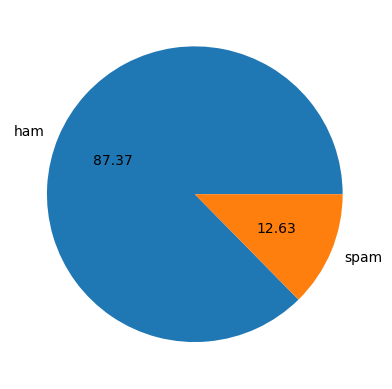

In [42]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [80]:
import nltk
nltk.download('punkt_tab','corpus')

[nltk_data] Downloading package punkt_tab to corpus...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [49]:
df['num char']=df['text'].apply(len)

In [50]:
df.head()

,target,text,num char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [53]:
df['num word']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [57]:
df['num sententence']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [58]:
df.head()

,target,text,num char,num word,num sententence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [59]:
df.describe()

,target,num char,num word,num sententence
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [60]:
df[df['target']==0].describe()

,target,num char,num word,num sententence
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,17.123782,1.820195
std,0.0,56.358207,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [61]:
df[df['target']==1].describe()

,target,num char,num word,num sententence
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,27.667688,2.970904
std,0.0,30.137753,7.008418,1.488425
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,25.000000,2.000000
50%,1.0,149.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,224.000000,46.000000,9.000000


In [62]:
import seaborn as sns

<Axes: xlabel='num char', ylabel='Count'>

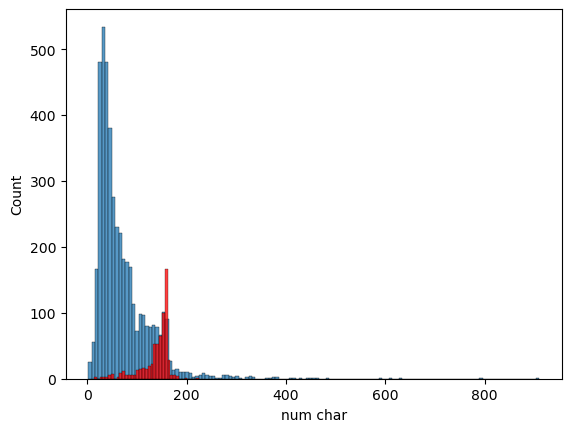

In [64]:
sns.histplot(df[df['target']==0]['num char'])
sns.histplot(df[df['target']==1]['num char'],color='red')

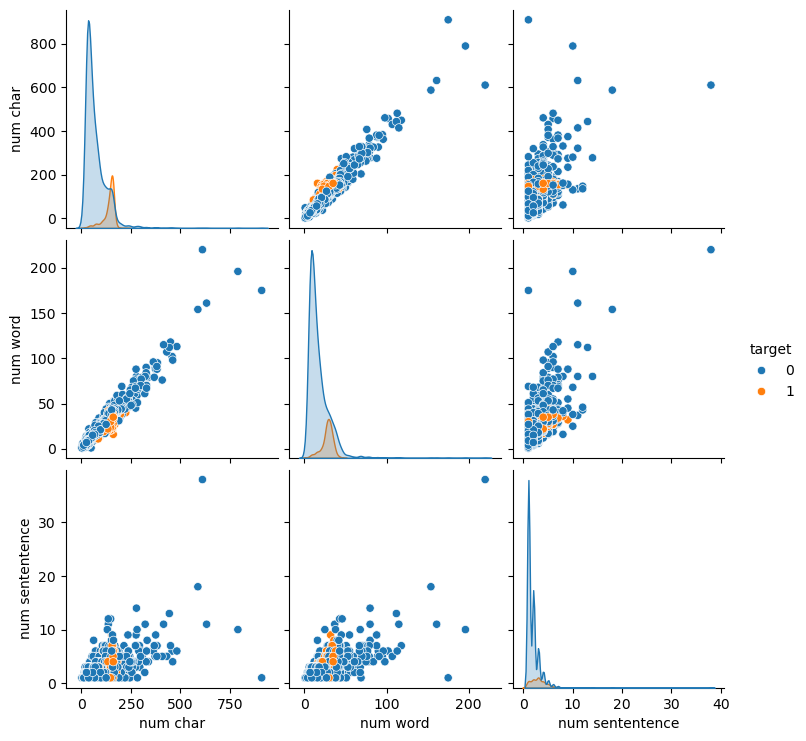

In [66]:
sns.pairplot(df,hue='target')

<Axes: >

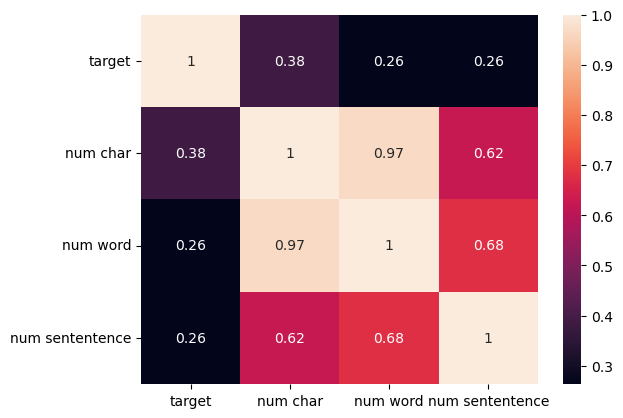

In [69]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data preproccessing
### . Lower case
### . Tokenization
### . Removing Special characters
### . Stemming

In [82]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91899\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [86]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [95]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('dancing')

'danc'

In [98]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
            
    return " ".join(y)

In [101]:
transform_text('i love the Youtube lecture on ml ?')

'love youtub lectur ml'

In [92]:
from nltk.corpus import stopwords
stopwords.words('english')[:10]

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [102]:
df['transformed_text']=df['text'].apply(transform_text)

In [103]:
df.sample(5)

,target,text,num char,num word,num sententence,transformed_text
4034,1,YOU ARE CHOSEN TO RECEIVE A å£350 AWARD! Pls c...,159,30,2,chosen receiv award pl call claim number 09066...
1822,0,If you're thinking of lifting me one then no.,45,11,1,think lift one
397,0,You are always putting your business out there...,221,49,4,alway put busi put pictur ass facebook one ope...
4418,0,How have your little darlings been so far this...,124,28,2,littl darl far week need coffe run tomo ca bel...
3603,0,Hey morning what you come to ask:-) pa...,41,12,1,hey morn come ask pa


In [108]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [109]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

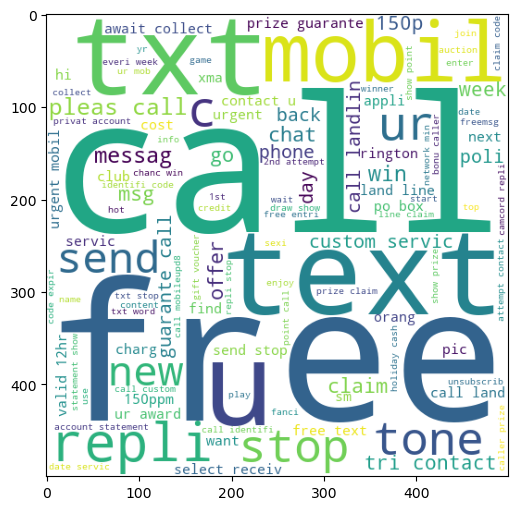

In [110]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [112]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [114]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=""))

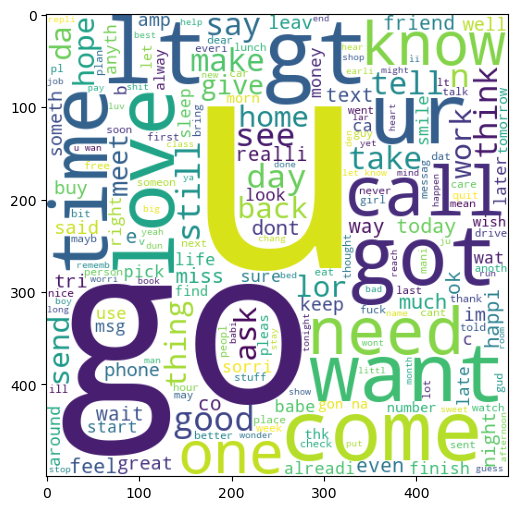

In [116]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [118]:
df.head()

,target,text,num char,num word,num sententence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [121]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for words in msg.split():
        spam_corpus.append(words)

In [122]:
len(spam_corpus)

9939

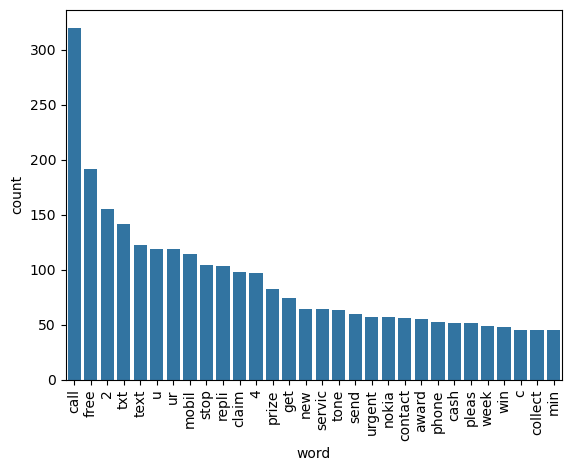

In [128]:
data = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

sns.barplot(data=data, x='word', y='count')

plt.xticks(rotation='vertical')
plt.show()

In [129]:
spam_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for words in msg.split():
        spam_corpus.append(words)

In [130]:
len(spam_corpus)

35404

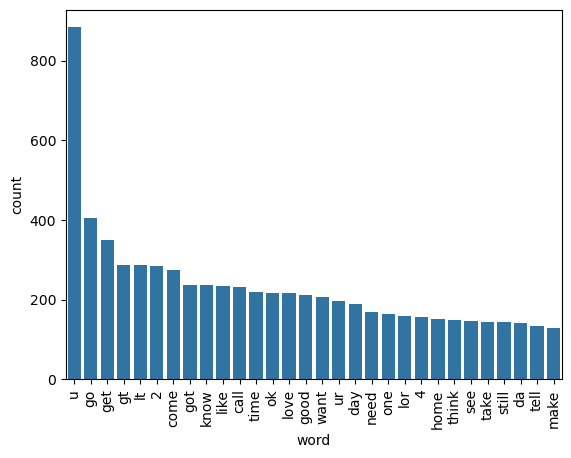

In [131]:
data = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

sns.barplot(data=data, x='word', y='count')

plt.xticks(rotation='vertical')
plt.show()

In [133]:
df.head()

,target,text,num char,num word,num sententence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# Model Building

In [135]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()

In [136]:
x=cv.fit_transform(df['transformed_text']).toarray()

In [137]:
x.shape

(5169, 6708)

In [138]:
y=df['target'].values

In [139]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [140]:
from sklearn.model_selection import train_test_split

In [141]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [143]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [145]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [146]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [148]:
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8684719535783365
[[772 117]
 [ 19 126]]
0.5185185185185185


In [149]:
mnb.fit(x_train,y_train)
y_pred2=mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9738878143133463
[[872  17]
 [ 10 135]]
0.8881578947368421


In [150]:
bnb.fit(x_train,y_train)
y_pred3=bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


# Using Tfidf vectorizer

In [153]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfid = TfidfVectorizer()

x_n = tfid.fit_transform(df['transformed_text']).toarray()

In [154]:
y=df['target'].values

In [155]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_n,y,random_state=42,test_size=0.2)

In [156]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [157]:
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8636363636363636
[[772 117]
 [ 24 121]]
0.5084033613445378


In [158]:
mnb.fit(x_train,y_train)
y_pred2=mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9613152804642167
[[888   1]
 [ 39 106]]
0.9906542056074766


In [159]:
bnb.fit(x_train,y_train)
y_pred3=bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542
